<div style="background-color:#f5f3ff; border-radius:8px; padding:12px; text-align:center;">

# **PRACTICA 2: Juego de Tronos · VISUALIZACIÓN DE DATOS**

</div>

*Visualización de Juego de Tronos*

---

**Grupo:** G-7312  
**Número de pareja:** 01  
**Miembros:**  
- Leire Bernárdez Vázquez  
- Carmen Reiné Rueda


---

### **CONFIGURACIONES PREVIAS**

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Importaciones
</div>

In [40]:
import numpy as np
import pandas as pd
import json
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import networkx as nx       
import geopandas as gpd      
from folium.plugins import MarkerCluster
from collections import Counter

In [41]:
# === CARGA DE LOS DATOS ===

# Rutas base
ruta_data = r"C:\Users\carme\OneDrive - UAM\TERCERO\PRIMER CUATRI\VD\PRACTICAS\VD_G7312_P02\game_of_thrones\data"
ruta_map = r"C:\Users\carme\OneDrive - UAM\TERCERO\PRIMER CUATRI\VD\PRACTICAS\VD_G7312_P02\GOT-Map\GOT-Map"

# --- Carga de archivos JSON principales ---
with open(os.path.join(ruta_data, "characters.json"), "r", encoding="utf-8") as f:
    characters = json.load(f)

with open(os.path.join(ruta_data, "episodes.json"), "r", encoding="utf-8") as f:
    episodes = json.load(f)

with open(os.path.join(ruta_data, "locations.json"), "r", encoding="utf-8") as f:
    locations = json.load(f)

# --- Carga de archivos GeoJSON (mapas) ---
land = gpd.read_file(os.path.join(ruta_map, "land.geojson"))
places = gpd.read_file(os.path.join(ruta_map, "places.geojson"))

---


### **EJERCICIOS**



### <span >**Parte 1: Visualización de grafos con NetworkX**

En esta primera parte trabajaremos con las relaciones existentes entre los personajes de la serie *Game of Thrones* utilizando la librería **NetworkX**.  
El objetivo es construir el grafo de relaciones, obtener métricas y justificar las decisiones de diseño adoptadas (tipo de grafo, relaciones representadas, tamaño y color de nodos, y layout empleado).




<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Apartado 1: Construcción del grafo de relaciones
</div>



A partir del fichero `characters.json`, construiremos un grafo donde los nodos representen personajes y las aristas indiquen algún tipo de relación entre ellos (parentesco, conflicto, etc.).


Antes de construir el grafo, realizamos una exploración básica del fichero para conocer cuántos personajes contiene, si hay registros sin nombre o duplicados, y qué información incluye. También miraremos todas los campos presentes en el dataset para distinguir cuáles son atributos descriptivos (nombre, actor, casa, etc.) y cuáles representan **relaciones entre personajes**.


In [42]:
data_chars = characters["characters"]
print(f"Personajes totales (sin limpieza): {len(data_chars)}")

# ¿Hay personajes SIN nombre?
sin_nombre = [i for i,c in enumerate(data_chars) if not c.get("characterName")]
print("\nSin nombre:", len(sin_nombre))

# ¿Hay nombres duplicados?
contador = Counter([c["characterName"] for c in data_chars if c.get("characterName")])
duplicados = [n for n,c in contador.items() if c>1]
print("\nDuplicados:", len(duplicados))
if duplicados:
    print(duplicados[:])  
    
# Todas los campos posibles en el JSON
todos_los_campos = sorted({k for c in data_chars for k in c.keys()})
print("\nTotal de campos en el JSON:", len(todos_los_campos))
print(todos_los_campos)


Personajes totales (sin limpieza): 389

Sin nombre: 0

Duplicados: 15
['Goldcloak', 'Handmaid', 'High Septon', 'Lannister Captain', 'Little Bird', 'Musician #1', 'Musician #2', 'Musician #3', "Night's Watch Officer", "Night's Watchman", "Night's Watchman #2", 'Red Priestess', 'Septon', 'Stark Guard', 'White Walker']

Total de campos en el JSON: 25
['abducted', 'abductedBy', 'actorLink', 'actorName', 'actors', 'allies', 'characterImageFull', 'characterImageThumb', 'characterLink', 'characterName', 'guardedBy', 'guardianOf', 'houseName', 'killed', 'killedBy', 'kingsguard', 'marriedEngaged', 'nickname', 'parentOf', 'parents', 'royal', 'servedBy', 'serves', 'sibling', 'siblings']


Estos personajes duplicados no son errores, sino roles genéricos o figurantes sin relevancia narrativa.  
Posteriormente se eliminarán para simplificar el grafo y centrarnos en los personajes principales.  


**1. Explora los tipos de relaciones disponibles en el fichero y selecciona al menos tres ipos diferentes para incluir en el grafo.**

El dataset contiene 25 campos diferentes, hemos seleccionado únicamente aquellos campos que representan vínculos entre personajes (por ejemplo: parents, parentOf, siblings, killed, killedBy, marriedEngaged, etc.).  
El resto de atributos descriptivos (como characterName, actorName, houseName, etc.) se mantendrán solo si aportan información adicional en el grafo.

In [43]:
# Campos que consideramos "de relación" según el JSON real
relaciones_validas = {
    "parents", "parentOf", "siblings", "sibling",
    "killed", "killedBy",
    "marriedEngaged",
    "servedBy", "serves",
    "guardianOf", "guardedBy",
    "allies", "abducted", "abductedBy"
}

# Las que son realmente relaciones
relaciones_personajes = sorted({k for k in todos_los_campos if k in relaciones_validas})
print("\nSolo las campos que son relaciones válidas:", len(relaciones_personajes))
print("Tipos de relaciones presentes:", relaciones_personajes)




Solo las campos que son relaciones válidas: 14
Tipos de relaciones presentes: ['abducted', 'abductedBy', 'allies', 'guardedBy', 'guardianOf', 'killed', 'killedBy', 'marriedEngaged', 'parentOf', 'parents', 'servedBy', 'serves', 'sibling', 'siblings']


**Limpieza del dataset: eliminación de duplicados y columnas no necesarias**

Antes de construir el grafo, realizamos una limpieza del dataset para eliminar:

- Personajes genéricos o duplicados, que no aportan relaciones significativas.
- Columnas que no son relevantes para la práctica, como los enlaces de actor o las imágenes, ya que no influyen en la estructura del grafo.

Dejaremos únicamente los campos necesarios para representar nodos y relaciones válidas .

In [44]:
# Personajes genéricos o repetidos
nombres_duplicados = 'Goldcloak', 'Handmaid', 'High Septon', 'Lannister Captain', 'Little Bird', 'Musician #1', 'Musician #2', 'Musician #3', "Night's Watch Officer", "Night's Watchman", "Night's Watchman #2", 'Red Priestess', 'Septon', 'Stark Guard', 'White Walker'

# Campos relevantes: nombre, casa, estatus real y relaciones útiles
campos = ['characterName', 'houseName', 'royal', "kingsguard", "nickname"]

campos_utiles = campos + relaciones_personajes

# Crear nuevo dataset filtrado
data_chars_limpio = []

for c in data_chars:
    nombre = c.get("characterName")
    # Saltamos los personajes duplicados o sin nombre
    if not nombre or nombre in nombres_duplicados:
        continue

    # Conservamos solo las columnas útiles (atributos + relaciones)
    limpio = {k: c[k] for k in campos_utiles if k in c}
    data_chars_limpio.append(limpio)

print(f"Personajes antes de limpiar: {len(data_chars)}")
print(f"Personajes después de limpiar: {len(data_chars_limpio)}")

# Comprobamos algunos campos del primer registro limpio
print("\nEjemplo de estructura limpia:")
for k, v in data_chars_limpio[1].items():
    print(f"- {k}: {v }")

Personajes antes de limpiar: 389
Personajes después de limpiar: 355

Ejemplo de estructura limpia:
- characterName: Aegon Targaryen
- houseName: Targaryen
- royal: True
- killedBy: ['Gregor Clegane']
- parents: ['Elia Martell', 'Rhaegar Targaryen']
- siblings: ['Rhaenys Targaryen', 'Jon Snow']


El archivo limpio se guarda como `characters_clean.json` y servirá como base para el resto de la práctica.


In [45]:
# === GUARDAR EL NUEVO JSON LIMPIO ===
ruta_salida = os.path.join(ruta_data, "characters_clean.json")

with open(ruta_salida, "w", encoding="utf-8") as f:
    json.dump(data_chars_limpio, f, ensure_ascii=False, indent=3)

print(f"\nArchivo limpio guardado correctamente en:\n{ruta_salida}")
print(f"Total de personajes guardados: {len(data_chars_limpio)}")



Archivo limpio guardado correctamente en:
C:\Users\carme\OneDrive - UAM\TERCERO\PRIMER CUATRI\VD\PRACTICAS\VD_G7312_P02\game_of_thrones\data\characters_clean.json
Total de personajes guardados: 355


**2. Decide qué relaciones deben representarse como dirigidas y cuáles como no 
dirigidas**

In [46]:
# === CARGA DEL JSON LIMPIO ===
ruta_clean = os.path.join(ruta_data, "characters_clean.json")
with open(ruta_clean, "r", encoding="utf-8") as f:
    personajes = json.load(f)

# === DETECTAMOS RELACIONES PRESENTES Y SU FRECUENCIA ===
rel_counter = Counter()

for c in personajes:
    for k, v in c.items():
        if isinstance(v, list): 
            rel_counter[k] += len(v)

print("\nTipos de relaciones encontradas y su frecuencia total:")
for rel, n in rel_counter.most_common():
    print(f"- {rel}: {n}")

# Cuántos personajes tienen al menos una relación
personajes_con_rel = sum(
    any(isinstance(v, list) and len(v) > 0 for v in c.values())
    for c in personajes
)
print(f"\nPersonajes con al menos una relación: {personajes_con_rel}")



Tipos de relaciones encontradas y su frecuencia total:
- killed: 221
- killedBy: 203
- siblings: 134
- parents: 81
- parentOf: 78
- marriedEngaged: 55
- serves: 22
- guardianOf: 15
- guardedBy: 12
- servedBy: 10
- houseName: 10
- allies: 8
- sibling: 2
- abductedBy: 1
- abducted: 1

Personajes con al menos una relación: 226


A partir del análisis de frecuencias realizado, observamos que hay relaciones principales y otras aparecen con poca frecuencia y no aportan una estructura suficientemente rica para el grafo general.

Basándonos en estos resultados y en los ejemplos comentados en clase, hemos decidido centrarnos en **tres tipos de relaciones significativas**:
- **killed** → relación dirigida, representa un conflicto donde un personaje mata a otro (A → B).  
- **siblings** → relación no dirigida, representa vínculos de hermandad mutua.  
- **parents** → relación no dirigida, representa lazos familiares entre padres e hijos sin sentido de dirección.

De este modo, construiremos un **grafo mixto**, ya que combina relaciones **dirigidas** (de conflicto)  y **no dirigidas** (de tipo familiar o de parentesco), reflejando tanto los enfrentamientos como los lazos de sangre entre los personajes.



**3. Crea el grafo en NetworkX, añadiendo atributos a las aristas que indiquen el tipo de 
relación.**

En este apartado construiremos el grafo de relaciones a partir del archivo characters_clean.json.

Cada **nodo** representará un personaje,  y cada **arista** una relación entre dos personajes (conflicto, hermandad o parentesco).

In [47]:
# === CREAR GRAFO MIXTO ===
G = nx.MultiDiGraph()  # permite direccionalidad mixta (dirigida y no dirigida simulada)

# === AÑADIR NODOS ===
for p in personajes:
    nombre = p["characterName"]
    G.add_node(nombre, house=p.get("houseName"), royal=p.get("royal"))

# === AÑADIR RELACIONES DIRIGIDAS (killed) ===
for p in personajes:
    origen = p["characterName"]
    if "killed" in p:
        for destino in p["killed"]:
            if destino != origen:
                G.add_edge(origen, destino, relation="killed", directed=True)

# === AÑADIR RELACIONES NO DIRIGIDAS (siblings, parents) ===
for p in personajes:
    origen = p["characterName"]
    for tipo in ["siblings", "parents"]:
        if tipo in p:
            for destino in p[tipo]:
                if destino != origen:
                    # Añadimos dos direcciones opuestas para simular una arista no dirigida
                    G.add_edge(origen, destino, relation=tipo, directed=False)
                    G.add_edge(destino, origen, relation=tipo, directed=False)

# === RESUMEN ===
print(f"Nodos totales: {G.number_of_nodes()}")
print(f"Aristas totales: {G.number_of_edges()}")

tipos_rel = [d["relation"] for _, _, d in G.edges(data=True)]
for rel, n in Counter(tipos_rel).items():
    print(f"- {rel}: {n}")

Nodos totales: 408
Aristas totales: 647
- siblings: 268
- parents: 162
- killed: 217


>❓ **Duda para el profesor:**  
>
>En el dataset aparecen casos como el de `Janos Slynt`, que incluye la relación `"killed": ["Barra"]`,  
>pero *Barra* no figura como personaje en el JSON (no tiene `characterName` ni relaciones propias).  
>
>¿Debemos considerar este tipo de menciones ("Barra", "Faith Militant", "Roof collapse", etc.)  
>como **relaciones válidas** dentro del grafo (aunque generen nodos sin atributos),  
>o deben eliminarse al tratarse de **entidades narrativas no definidas** (eventos, grupos o víctimas sin presencia individual)?  


In [48]:
# Todos los nombres originales
nombres_originales = {p["characterName"] for p in personajes}

# Nodos añadidos automáticamente
nodos_extra = [n for n in G.nodes if n not in nombres_originales]

print(f"Nodos totales en el grafo: {G.number_of_nodes()}")
print(f"Personajes originales: {len(nombres_originales)}")
print(f"Nodos adicionales detectados: {len(nodos_extra)}")

if nodos_extra:
    print("Ejemplos de nodos adicionales:", nodos_extra[:])

# --- (Opcional) Eliminar los nodos inválidos ---
# ----------------------------------------------------------
# Descomentar si el profesor confirma que deben eliminarse:
#
# G.remove_nodes_from(nodos_extra)
# print(f"\nNodos después de limpiar: {G.number_of_nodes()}")
# print(f"Aristas después de limpiar: {G.number_of_edges()}")
# Contar aristas por tipo
# rel_por_tipo = Counter(nx.get_edge_attributes(G, 'relation').values())

# print("Distribución de aristas por tipo de relación:")
# for tipo, n in rel_por_tipo.items():
#    print(f"- {tipo}: {n}")
# ----------------------------------------------------------


Nodos totales en el grafo: 408
Personajes originales: 355
Nodos adicionales detectados: 53
Ejemplos de nodos adicionales: ['Frey Soldier #1', 'Ghita', 'White Walker', 'Soldier Tom', 'Bolton Officer', 'Oznak zo Pahl', 'Iggo', 'Khal Brozho', 'Khal Qorro', 'Khal Forzho', 'Eleanor', "Eleanor's Daughter", 'Zalla', 'Kevin Eldon', 'Laurence Spellman', "King's Landing Boaster", 'Faith Militant', 'Rennick', 'Belicho Paenymion', 'Torrhen Karstark', 'Barra', 'Despondent Man', 'Norvoshi Pit Fighter', 'Meereenese Champion', 'Donnel Hill', 'Cooper', 'Axell Florent', 'Son of the Harpy', 'Bolton Soldier', 'Master Torturer', 'Medger Cerwyn', 'Lady Cerwyn', 'Unidentified Cerwyn', 'Old Woman', 'Kings Landing Rioter #1', 'Kings Landing Rioter #2', 'Kings Landing Rioter #3', 'Frey Soldier #2', 'Lowell', 'Dying Man', 'Steve', 'Riddell', 'Morgan', 'Gordy', 'Simpson', "Olly's Mother", 'Tortured Prisoner', 'Harrag', 'Maester Caleotte', 'Old Man', 'Guymon', "Mole's Town Whore", 'Catelyn Tully']


El grafo resultante integra los tres tipos de relaciones seleccionadas (killed, siblings y parents),combinando vínculos dirigidos (conflictos) y no dirigidos (familiares).

Nodos totales: 408
De ellos, 355 corresponden a personajes reales del dataset original y 53 son nodos adicionalesque aparecen en las relaciones pero no figuran como personajes definidos (por ejemplo: Barra, Faith Militant, Roof collapse…).
Estos nodos podrían considerarse entidades narrativas sin atributos propios.

Aristas totales: 647
La mayoría de las conexiones provienen de vínculos familiares (siblings y parents), mientras que las relaciones de conflicto (killed) aportan una red más dispersa.
Esta diferencia refleja la importancia de las casas y linajes frente a los enfrentamientos individuales.

En conjunto, el grafo describe una red coherente donde los lazos de sangre y los actos de violencia estructuran gran parte de las conexiones entre personajes.

**La posible eliminación de los nodos “no definidos” queda pendiente de confirmación por parte del profesor.**

**4. Realiza una primera visualización del grafo completo, diferenciando visualmente 
los tipos de relaciones mediante colores o estilos de línea.**

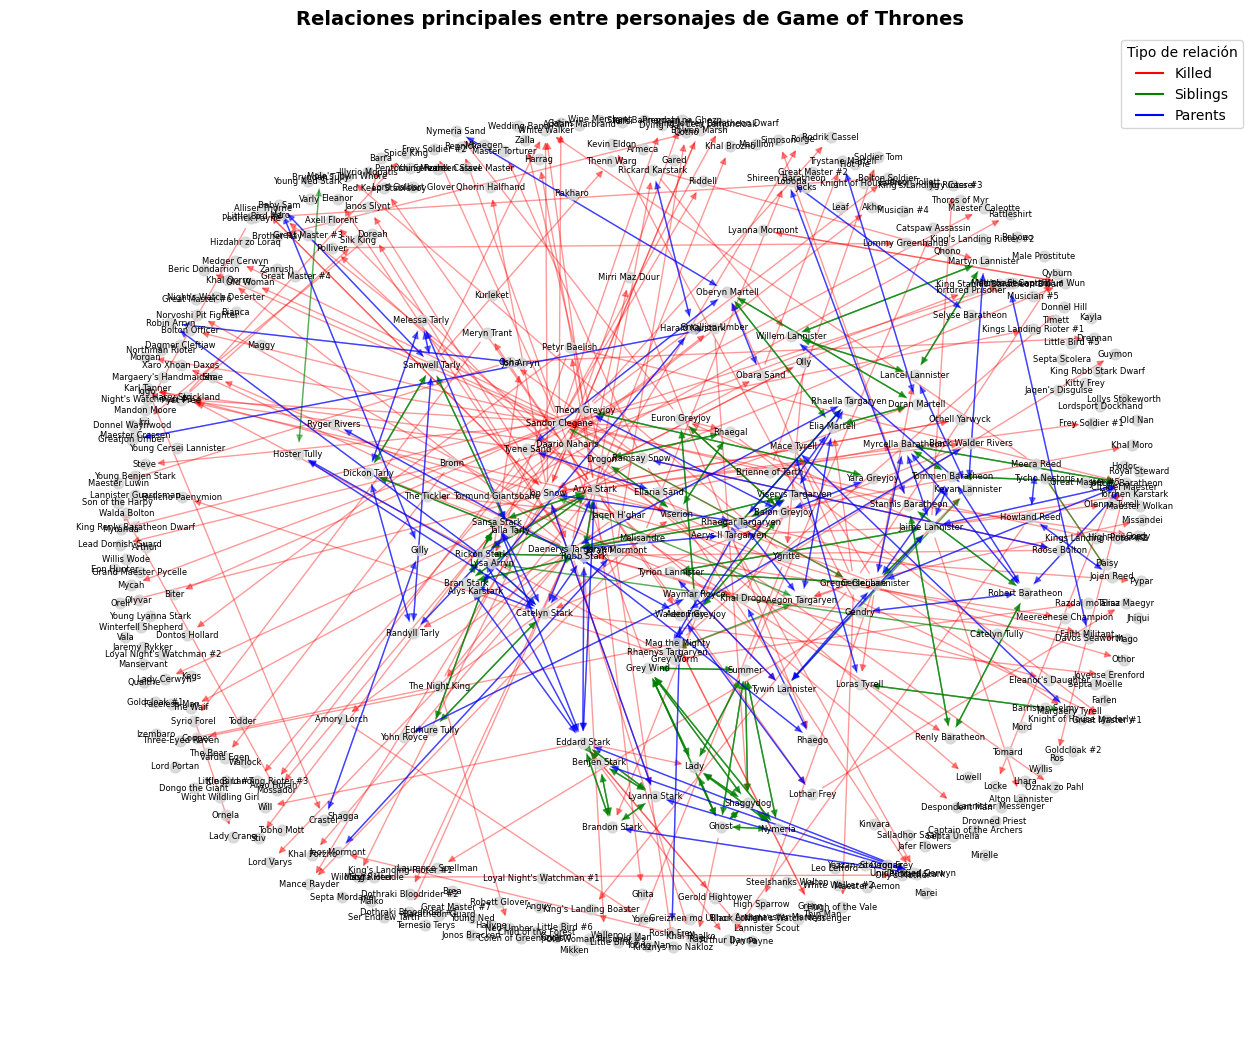

In [ ]:
# === CONFIGURACIÓN DE COLORES Y LAYOUT ===

# Calculamos posiciones para los nodos (layout)
pos = nx.spring_layout(G, k=0.5, seed=42) # k controla la distancia media entre nodos; seed da estabilidad al gráfico

# Creamos listas de aristas separadas por tipo para dibujarlas con distinto color
edges_killed = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "killed"]
edges_siblings = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "siblings"]
edges_parents = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "parents"]

# === VISUALIZACIÓN INICIAL DEL GRAFO ===
plt.figure(figsize=(16, 13))
plt.title("Relaciones principales entre personajes de Game of Thrones", fontsize=14, fontweight='bold')

# Dibujamos nodos (mismo tamaño por ahora)
nx.draw_networkx_nodes(G, pos, node_size=60, node_color="lightgray", alpha=0.8)

# Dibujamos aristas por tipo de relación
nx.draw_networkx_edges(G, pos, edgelist=edges_killed, edge_color="red", alpha=0.4, arrows=True)
nx.draw_networkx_edges(G, pos, edgelist=edges_siblings, edge_color="green", alpha=0.4)
nx.draw_networkx_edges(G, pos, edgelist=edges_parents, edge_color="blue", alpha=0.5)

# Añadimos algunos nombres de personajes (uno de cada 35 nodos)
nx.draw_networkx_labels(G, pos, font_size=6, font_color="black")

import matplotlib.lines as mlines
legend_handles = [
    mlines.Line2D([], [], color='red', label='Killed'),
    mlines.Line2D([], [], color='green', label='Siblings'),
    mlines.Line2D([], [], color='blue', label='Parents')
]
plt.legend(handles=legend_handles, title="Tipo de relación", loc="upper right")

plt.axis("off")
plt.show()



En este primer gráfico se representa el conjunto completo de personajes y relaciones seleccionadas

Cada tipo de relación se ha diferenciado visualmente por color:
- 🔴 **Killed** → relaciones de conflicto (dirigidas)
- 🟢 **Siblings** → lazos de hermandad (no dirigidas)
- 🔵 **Parents** → vínculos de parentesco (no dirigidas)

Se ha empleado el layout **spring_layout**, que equilibra la distancia entre nodos para facilitar la lectura de la red.  
Los nodos con mayor número de conexiones tienden a situarse en el centro, mostrando las familias más relevantes de la serie.
  
Esta primera visualización permite observar la estructura general de la red antes de aplicar criterios más detallados.

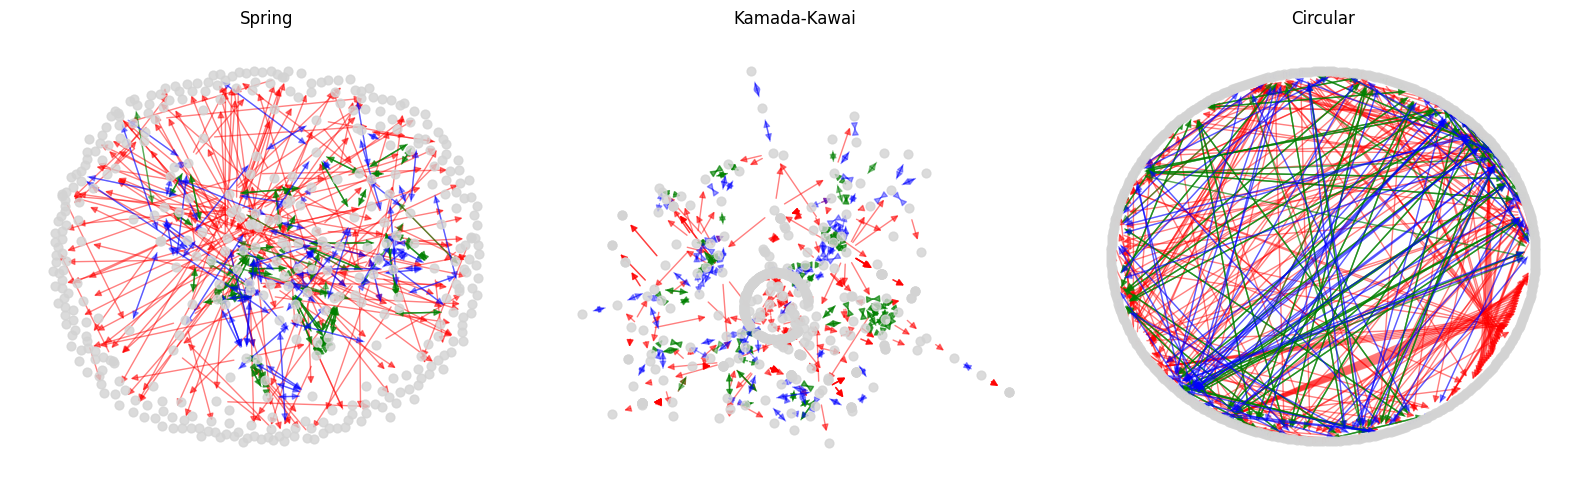

In [65]:
# === COMPARACIÓN DE LAYOUTS ===
layouts = {
    "Spring": nx.spring_layout(G, k=0.4, seed=42),
    "Kamada-Kawai": nx.kamada_kawai_layout(G),
    "Circular": nx.circular_layout(G)
}

plt.figure(figsize=(16, 5))
for i, (name, pos_i) in enumerate(layouts.items(), 1):
    plt.subplot(1, 3, i)
    plt.title(name, fontsize=12)
    nx.draw_networkx_nodes(G, pos_i, node_size=40, node_color="lightgray", alpha=0.8)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_killed, edge_color="red", alpha=0.5)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_siblings, edge_color="green", alpha=0.4)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_parents, edge_color="blue", alpha=0.4)
    plt.axis("off")
plt.tight_layout()
plt.show()


> ❓ **Duda para el profesor**
>
> En este apartado hemos probado varios *layouts* (`spring_layout`, `kamada_kawai_layout` y `circular_layout`) 
> para comparar cómo cambia la distribución visual del grafo.  
>
> ¿Prefiere que dejemos la **comparativa completa** (con los tres gráficos lado a lado para analizar las diferencias)  
> o que mostremos únicamente la **versión final elegida** con `spring_layout`, explicando brevemente que se 
> descartaron las demás por motivos de legibilidad?
>
> En clase comentó que bastaba con justificar el layout elegido, pero no sabemos si es mejor mostrar la comparación visual.
